In [1]:
import matplotlib.pyplot as plt
# from erddapClient import ERDDAP_Griddap
from netCDF4 import Dataset
import numpy as np
import xarray as xr
import pandas as pd
import cmocean
import datetime
import geopandas as gpd
from shapely.ops import linemerge
from shapely.geometry import Polygon
from matplotlib.path import Path

from mpl_toolkits.basemap import Basemap
from matplotlib import colors

In [3]:
# -- Load data --
file_id = Dataset('../../data/chl/chl_1998_2025_l4_month_multi_4k.nc')
ras  = file_id.variables["CHL"][:]
lat  = file_id.variables["latitude"][:]
lon  = file_id.variables["longitude"][:]
time = file_id.variables["time"][:]
file_id.close()

# -- Crop to region of interest: 18N-35N, 175W-130W --
lat_mask = (lat >= 18) & (lat <= 35)
lon_mask = (lon >= -175) & (lon <= -135)
lat = lat[lat_mask]
lon = lon[lon_mask]
ras = ras[:, lat_mask, :][:, :, lon_mask]

# -- Build date vector --
timedelta_vector = (time * np.timedelta64(1, 'D')).astype('timedelta64[ns]')
base_date   = np.datetime64('1900-01-01')
date_vector = base_date + timedelta_vector

In [4]:
from shapely.ops import linemerge, polygonize, unary_union

# -- Load and build the Hawaii CZ polygons --
gdf = gpd.read_file('../../data/eez/USMaritimeLimitsNBoundaries.shp')
hawaii = gdf[gdf['REGION'] == 'Hawaiian Islands']

# Get all CZ boundary lines and polygonize them
cz_lines = hawaii[hawaii['CZ'] == 1.0]
merged_lines = unary_union(cz_lines.geometry)
cz_polys = list(polygonize(merged_lines))
cz_combined = unary_union(cz_polys)

# -- Create a 2D mask on the lat/lon grid --
lon_grid, lat_grid = np.meshgrid(lon, lat)
points = np.column_stack((lon_grid.ravel(), lat_grid.ravel()))

# Build path(s) for point-in-polygon test
from shapely.geometry import MultiPolygon
if isinstance(cz_combined, Polygon):
    cz_combined = MultiPolygon([cz_combined])

inside = np.zeros(len(points), dtype=bool)
for poly in cz_combined.geoms:
    p = Path(np.array(poly.exterior.coords))
    inside |= p.contains_points(points)

inside = inside.reshape(lon_grid.shape)

# -- Apply mask: set pixels inside the CZ to NaN --
ras[:, inside] = np.nan

In [5]:
# Extract month number (1-12) for each time step
months = date_vector.astype('datetime64[M]').astype(int) % 12 + 1

# Compute median monthly climatology (12 months, each pixel)
monthly_clim = np.zeros((12, ras.shape[1], ras.shape[2]))
for m in range(1, 13):
    monthly_clim[m - 1, :, :] = np.nanmedian(ras[months == m, :, :], axis=0)

# Subtract the climatology from each time step
ras_anom = np.zeros_like(ras)
for i in range(ras.shape[0]):
    ras_anom[i, :, :] = ras[i, :, :] - monthly_clim[months[i] - 1, :, :]

/tmp/ipykernel_718401/4094170435.py:7: RuntimeWarning: All-NaN slice encountered
  monthly_clim[m - 1, :, :] = np.nanmedian(ras[months == m, :, :], axis=0)


In [ ]:
# Compute per-pixel mean and standard deviation across all time steps
pixel_mean = np.nanmean(ras, axis=0)  # shape: (lat, lon)
pixel_std  = np.nanstd(ras, axis=0)   # shape: (lat, lon)
# Create mask: +1 = above mean+1std, -1 = below mean-1std, 0 = within normal range
ras_mask = np.zeros_like(ras)
ras_mask[ras > pixel_mean + pixel_std*1] =  1
# ras_mask[ras < pixel_mean - pixel_std] = -1

ras_extreme = np.where(ras_mask == 1, ras, np.nan)

/tmp/ipykernel_718401/608170063.py:2: RuntimeWarning: Mean of empty slice
  pixel_mean = np.nanmean(ras, axis=0)  # shape: (lat, lon)
/home/jamesash/anaconda3/envs/uhdas/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [8]:
# Define the 22 start/end date pairs
start_dates = [
    '1998-07-08', '1999-08-01', '2000-08-15', '2001-07-18',
    '2002-06-15', '2003-07-26', '2004-06-03', '2005-07-02', '2006-07-22',
    '2007-08-15', '2008-08-10', '2009-06-13', '2010-07-01', '2011-09-07',
    '2012-09-01', '2013-07-10', '2014-06-14', '2015-08-01', '2016-08-02',
    '2017-07-15', '2018-07-16', '2019-06-11', '2020-08-10', '2021-08-01',
    '2022-07-01'
]

end_dates = [
    '1998-10-06', '1999-10-12', '2000-11-15', '2001-08-04',
    '2002-09-10', '2003-10-08', '2004-08-11', '2005-10-02', '2006-11-11',
    '2007-11-07', '2008-10-22', '2009-10-10', '2010-09-28', '2011-11-12',
    '2012-11-06', '2013-10-02', '2014-09-01', '2015-10-01', '2016-09-25',
    '2017-09-05', '2018-10-27', '2019-09-08', '2020-09-08', '2021-10-01',
    '2022-10-10'
]

# Convert to numpy datetime64
start_dates = np.array(start_dates, dtype='datetime64[D]')
end_dates   = np.array(end_dates, dtype='datetime64[D]')

# Subset and compute grand mean for each date pair
mag_list = []
for s, e in zip(start_dates, end_dates):
    mask = (date_vector >= s) & (date_vector <= e)
    subset = ras_extreme[mask, :, :]
    u = np.nanmean(subset)
    o = np.nanstd(subset)
    mag_list.append(u+2*o) # 2D mean map (lat, lon)

In [9]:
from scipy.ndimage import center_of_mass
center_list = []
for s, e in zip(start_dates, end_dates):
    mask = (date_vector >= s) & (date_vector <= e)
    subset_dates = date_vector[mask]
    subset = np.where(np.isnan(ras_extreme[mask, :, :]), 0, ras_extreme[mask, :, :])
    
    # Skip if no extreme pixels exist in this window
    if np.sum(subset) == 0:
        center_list.append({
            'start': str(s),
            'end': str(e),
            'date': 'N/A',
            'lat': np.nan,
            'lon': np.nan
        })
        continue
    
    t_idx, lat_idx, lon_idx = center_of_mass(subset)
    t_round = int(round(t_idx))
    t_round = min(t_round, len(subset_dates) - 1)
    center_date = str(subset_dates[t_round])[:10]
    
    center_list.append({
        'start': str(s),
        'end': str(e),
        'date': center_date,
        'lat': lat[int(round(lat_idx))],
        'lon': lon[int(round(lon_idx))]
    })

In [10]:
df = pd.DataFrame(center_list)
df['magnitude'] = mag_list
df.to_csv('bloom_centers.csv', index=False)

In [11]:
for c in center_list:
    print(f"{c['start']} to {c['end']}: date={c['date']}, lat={c['lat']:.2f}, lon={c['lon']:.2f}")

1998-07-08 to 1998-10-06: date=1998-08-01, lat=22.85, lon=-161.73
1999-08-01 to 1999-10-12: date=1999-09-01, lat=25.65, lon=-149.77
2000-08-15 to 2000-11-15: date=2000-10-01, lat=26.90, lon=-151.77
2001-07-18 to 2001-08-04: date=2001-08-01, lat=21.56, lon=-155.60
2002-06-15 to 2002-09-10: date=2002-08-01, lat=24.94, lon=-157.94
2003-07-26 to 2003-10-08: date=2003-09-01, lat=27.65, lon=-147.23
2004-06-03 to 2004-08-11: date=2004-07-01, lat=27.06, lon=-148.27
2005-07-02 to 2005-10-02: date=2005-09-01, lat=21.60, lon=-152.35
2006-07-22 to 2006-11-11: date=2006-09-01, lat=26.10, lon=-150.90
2007-08-15 to 2007-11-07: date=2007-10-01, lat=29.19, lon=-154.02
2008-08-10 to 2008-10-22: date=2008-10-01, lat=25.27, lon=-156.06
2009-06-13 to 2009-10-10: date=2009-09-01, lat=22.98, lon=-158.44
2010-07-01 to 2010-09-28: date=2010-07-01, lat=22.35, lon=-169.10
2011-09-07 to 2011-11-12: date=2011-11-01, lat=24.06, lon=-151.81
2012-09-01 to 2012-11-06: date=2012-10-01, lat=21.31, lon=-158.60
2013-07-10

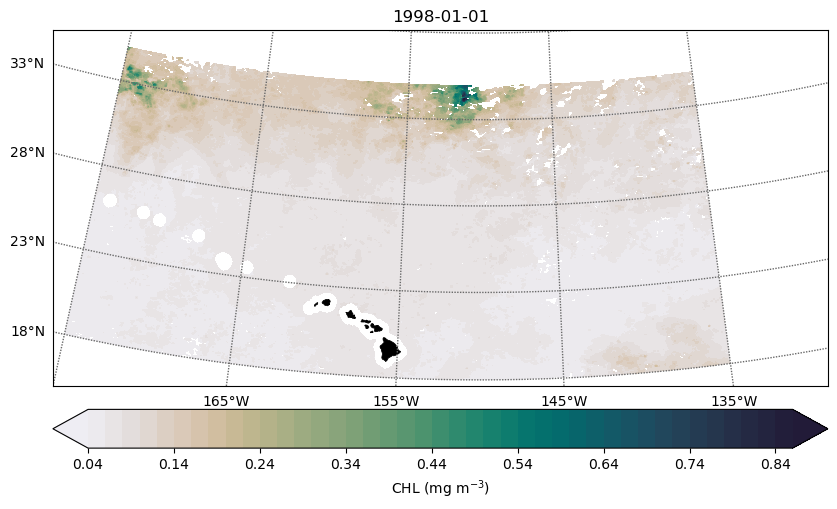

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

m = Basemap(projection='lcc', resolution='h',
            llcrnrlat=15, urcrnrlat=36,
            llcrnrlon=-175, urcrnrlon=-125,
            lat_0=30, lon_0=-150,
            width=5.1E6, height=5E6,
            ax=ax)

lon_grid, lat_grid = np.meshgrid(lon, lat)
x, y = m(lon_grid, lat_grid)

cp = m.contourf(x, y, ras[3, :, :], levels=50, cmap=cmocean.cm.rain, extend='both')
m.drawcoastlines(color='black', linewidth=0.5)
m.fillcontinents(color='black')
m.drawparallels(np.arange(18, 40, 5), labels=[1,0,0,0], fontsize=10, color='dimgrey')
m.drawmeridians(np.arange(-175, -125, 10), labels=[0,0,0,1], fontsize=10, color='dimgrey')

plt.colorbar(cp, ax=ax, orientation='horizontal', pad=0.05, label='CHL (mg m$^{-3}$)')
ax.set_title(str(date_vector[0])[:10])
plt.show()